[目录](./table_of_contents_cn.ipynb)

# 卡尔曼滤波器数学

In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

如果你读到了这里，我希望你会觉得卡尔曼滤波器令人生畏的名声多少有些名不副实。当然，我跳过了一些方程没有细讲，但我希望实现起来对你来说相当直截了当。其背后的概念非常简单——取两个测量值，或者一个测量值和一个预测，然后选择输出位于两者之间的某处。如果你更相信测量值，你的猜测就会更接近测量值；如果你相信预测更准确，你的猜测就会更靠近预测。这可不是火箭科学（开个小玩笑——正是这种数学把阿波罗送上了月球并让它返回！）。

说实话，我一直在小心地挑选问题。对于任意的问题，设计卡尔曼滤波器矩阵可能极其困难。不过我并没有*太过取巧*。像牛顿运动方程这样的方程，在卡尔曼滤波器的应用中可以很轻松地计算，而且它们构成了我们想要解决的这类问题的主体。

我一直用代码和推理而不是数学来阐明这些概念。但有些主题确实需要比我目前使用的更多的数学。本章介绍本书其余部分所需的数学。

## 对动态系统建模

*动态系统*是一个其状态（位置、温度等）随时间演化的物理系统。微积分是关于变化的量的数学，所以我们用微分方程来对动态系统建模。有些系统不能用微分方程建模，但我们在本书中不会遇到这些。

对动态系统建模严格来说是好几门大学课程的主题。在某种程度上，没有什么可以替代几个学期的常微分方程和偏微分方程，再加上一门控制系统理论的研究生课程。如果你是业余爱好者，或者试图在工作中解决一个非常具体的滤波问题，你可能没有时间和/或意愿花一年甚至更久的时间在这种教育上。

幸运的是，我可以介绍足够多的理论，使我们能够为许多不同的卡尔曼滤波器创建系统方程。我的目标是把你带到这样的阶段：你能够阅读一篇出版物，并且理解得足够好，以实现其中的算法。背景数学是深奥的，但在实践中我们最终只用到几个简单的技术。

这是本书中纯数学部分最长的一节。你需要掌握本节的所有内容，才能理解扩展卡尔曼滤波器 (EKF)，即最常见的非线性滤波器。我也会介绍不需要这么多数学的更现代的滤波器。你可以选择现在略读，如果你决定学习 EKF，再回来读这一节。

我们需要从理解卡尔曼滤波器所使用的基本方程和假设开始。我们试图对真实世界的现象建模，那么我们需要考虑什么？

每个物理系统都有一个过程。例如，一辆以某个速度行驶的汽车在固定时间内走一定距离，而它的速度随加速度变化。我们用我们在高中学到的那些著名的牛顿方程来描述这种行为。

$$
\begin{aligned}
v&=at\\
x &= \frac{1}{2}at^2 + v_0t + x_0
\end{aligned}
$$

学了微积分之后，我们看到它们是这种形式：

$$ \mathbf v = \frac{d \mathbf x}{d t},
\quad \mathbf a = \frac{d \mathbf v}{d t} = \frac{d^2 \mathbf x}{d t^2}
$$

一个典型的汽车跟踪问题会让你计算在恒定速度或加速度下行驶的距离，就像我们在前面的章节中所做的那样。但是，当然我们知道这并不是所发生的一切。没有哪辆车行驶在完美的道路上。有颠簸、风的阻力，还有使速度升高和降低的山坡。悬架是一个带有摩擦和不完美弹簧的机械系统。

完美地对一个系统建模是不可能的，除非是最平凡的问题。我们被迫做一个简化。在任意时刻 $t$，我们说真实状态（比如我们汽车的位置）是不完美模型的预测值加上某个未知的*过程噪声*：

$$
x(t) = x_{pred}(t) + noise(t)
$$

这并不意味着 $noise(t)$ 是一个我们可以解析推导出来的函数。这只是对事实的陈述——我们总是可以把真实值描述为预测值加上过程噪声。“噪声”并不意味着随机事件。如果我们在跟踪大气中一个被抛出的球，而我们的模型假设球在真空中，那么在这个语境下，空气阻力的影响就是过程噪声。

在下一节中，我们将学习把一组高阶微分方程转换为一组一阶微分方程的技术。转换之后，无噪声的系统模型是：

$$ \dot{\mathbf x} = \mathbf{Ax}$$

$\mathbf A$ 称为*系统动力学矩阵*，因为它描述了系统的动力学。现在我们需要对噪声建模。我们将其称为 $\mathbf w$，并把它加到方程中。

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf w$$

$\mathbf w$ 作为名字可能让你觉得选得不好，但你很快就会看到卡尔曼滤波器假设的是*白*噪声。

最后，我们需要考虑系统的任何输入。我们假设有一个输入 $\mathbf u$，并且存在一个线性模型来定义该输入如何改变系统。例如，踩下汽车的油门会使它加速，重力会使球下落。两者都是控制输入。我们需要一个矩阵 $\mathbf B$ 来把 $u$ 转换成对系统的影响。我们把它加到方程中：

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

就是这样。这就是 Kalman 博士着手求解的方程之一，而且如果我们对 $\mathbf w$ 假设了某些性质，他就找到了一个最优估计器。

## 动态系统的状态空间表示

我们已经推导出了方程

$$ \dot{\mathbf x} = \mathbf{Ax}+ \mathbf{Bu} + \mathbf{w}$$

然而，我们感兴趣的不是 $\mathbf x$ 的导数，而是 $\mathbf x$ 本身。暂时忽略噪声，我们想要一个方程，它能用时刻 $t_{k-1}$ 的 $\mathbf x$ 递归地求出时刻 $t_k$ 的 $\mathbf x$ 的值：

$$\mathbf x(t_k) = \mathbf F(\Delta t)\mathbf x(t_{k-1}) + \mathbf B(t_k)\mathbf u (t_k)$$

按照惯例，我们可以把 $\mathbf x(t_k)$ 写成 $\mathbf x_k$，它的意思是 $\mathbf x$ 在 $t$ 的第 $k^{th}$ 个值处的取值。

$$\mathbf x_k = \mathbf{Fx}_{k-1} + \mathbf B_k\mathbf u_k$$

$\mathbf F$ 就是我们熟悉的*状态转移矩阵*，因其能够在离散时间步之间转移状态的值而得名。它与系统动力学矩阵 $\mathbf A$ 非常相似。区别在于，$\mathbf A$ 对一组线性微分方程建模，是连续的。$\mathbf F$ 是离散的，表示一组线性方程（不是微分方程），它在离散的时间步 $\Delta t$ 上把 $\mathbf x_{k-1}$ 转移到 $\mathbf x_k$。

求这个矩阵往往相当困难。方程 $\dot x = v$ 是最简单的微分方程，我们可以轻松地对其积分：

$$ \int\limits_{x_{k-1}}^{x_k}  \mathrm{d}x = \int\limits_{0}^{\Delta t} v\, \mathrm{d}t $$
$$x_k-x_{k-1} = v \Delta t$$
$$x_k = v \Delta t + x_{k-1}$$

这个方程是*递归*的：我们基于时刻 $k-1$ 的值来计算时刻 $k$ 的 $x$ 的值。这种递归形式使我们能够把系统（过程模型）表示成卡尔曼滤波器所需要的形式：

$$\begin{aligned}
\mathbf x_k &= \mathbf{Fx}_{k-1}  \\
&= \begin{bmatrix} 1 & \Delta t \\ 0 & 1\end{bmatrix}
\begin{bmatrix}x_{k-1} \\ \dot x_{k-1}\end{bmatrix}
\end{aligned}$$

我们之所以能这样做，只是因为 $\dot x = v$ 是可能的最简单的微分方程。物理系统中几乎所有其他方程都会导致更复杂的微分方程，这种方法对它们不管用。

*状态空间*方法大约在阿波罗任务时期变得流行，这主要归功于 Kalman 博士的工作。思路很简单。用一组 $n^{th}$ 阶微分方程对系统建模。把它们转换成等价的一组一阶微分方程。把它们放入上一节使用的向量-矩阵形式：$\dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu}$。一旦有了这种形式，我们就用几种技术把这些线性微分方程转换成递归方程：

$$ \mathbf x_k = \mathbf{Fx}_{k-1} + \mathbf B_k\mathbf u_k$$

有些书把状态转移矩阵称为*基本矩阵*。许多书用 $\mathbf \Phi$ 代替 $\mathbf F$。大量基于控制理论的资料倾向于使用这些形式。

这些称为*状态空间*方法，是因为我们是用系统状态来表示微分方程的解。

### 由高阶方程构造一阶方程

许多物理系统的模型需要带有控制输入 $u$ 的二阶或更高阶微分方程：

$$a_n \frac{d^ny}{dt^n} + a_{n-1} \frac{d^{n-1}y}{dt^{n-1}} +  \dots + a_2 \frac{d^2y}{dt^2} + a_1 \frac{dy}{dt} + a_0 = u$$

状态空间方法需要一阶方程。任何高阶方程组都可以通过为导数定义额外的变量然后求解，而化为一阶。


我们来做一个例子。给定系统 $\ddot{x} - 6\dot x + 9x = u$，求等价的一阶方程。为清晰起见，我对时间导数使用了点记号。

第一步是把最高阶项隔离到方程的一侧。

$$\ddot{x} = 6\dot x - 9x + u$$

我们定义两个新变量：

$$\begin{aligned} x_1(t) &= x \\
x_2(t) &= \dot x
\end{aligned}$$

现在我们把它们代入原方程并求解。解会得到一组以这些新变量表示的一阶方程。为了记号方便，惯例是省去 $(t)$。

我们知道 $\dot x_1 = x_2$ 且 $\dot x_2 = \ddot{x}$。因此

$$\begin{aligned}
\dot x_2 &= \ddot{x} \\
         &= 6\dot x - 9x + u\\
         &= 6x_2-9x_1 + u
\end{aligned}$$

因此我们的一阶方程组是

$$\begin{aligned}\dot x_1 &= x_2 \\
\dot x_2 &= 6x_2-9x_1 + u\end{aligned}$$

如果你练习几次，就会变得熟练。隔离最高阶项，定义新变量及其导数，然后代入。

### 状态空间形式的一阶微分方程

把上一节中新定义的变量代入：

$$\frac{dx_1}{dt} = x_2,\,
\frac{dx_2}{dt} = x_3, \, ..., \,
\frac{dx_{n-1}}{dt} = x_n$$

代入一阶方程，得到：

$$\frac{dx_n}{dt} = \frac{1}{a_n}\sum\limits_{i=0}^{n-1}a_ix_{i+1} + \frac{1}{a_n}u
$$


使用向量-矩阵记号，我们有：

$$\begin{bmatrix}\frac{dx_1}{dt} \\ \frac{dx_2}{dt} \\ \vdots \\ \frac{dx_n}{dt}\end{bmatrix} =
\begin{bmatrix}\dot x_1 \\ \dot x_2 \\ \vdots \\ \dot x_n\end{bmatrix}=
\begin{bmatrix}0 & 1 & 0 &\cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
-\frac{a_0}{a_n} & -\frac{a_1}{a_n} & -\frac{a_2}{a_n} & \cdots & -\frac{a_{n-1}}{a_n}\end{bmatrix}
\begin{bmatrix}x_1 \\ x_2 \\ \vdots \\ x_n\end{bmatrix} +
\begin{bmatrix}0 \\ 0 \\ \vdots \\ \frac{1}{a_n}\end{bmatrix}u$$

我们把它写成 $\dot{\mathbf x} = \mathbf{Ax} + \mathbf{B}u$。

### 求时不变系统的基本矩阵

我们用状态空间形式来表示系统方程

$$ \dot{\mathbf x} = \mathbf{Ax}$$

其中 $\mathbf A$ 是系统动力学矩阵，我们想找到*基本矩阵* $\mathbf F$，它通过下面的方程在区间 $\Delta t$ 上传播状态 $\mathbf x$

$$\begin{aligned}
\mathbf x(t_k) = \mathbf F(\Delta t)\mathbf x(t_{k-1})\end{aligned}$$

换句话说，$\mathbf A$ 是一组连续的微分方程，而我们需要 $\mathbf F$ 是一组离散的线性方程，用来计算 $\mathbf A$ 在一个离散时间步上的变化。

惯例是省去 $t_k$ 和 $(\Delta t)$，使用记号

$$\mathbf x_k = \mathbf {Fx}_{k-1}$$

大体上说，卡尔曼滤波器中有三种常见的方法来求这个矩阵。最常使用的技术是矩阵指数。线性时不变理论（也称 LTI 系统理论）是第二种技术。最后，还有数值技术。你可能还知道别的，但这三种是你在卡尔曼滤波器文献和实践中最可能遇到的。

### 矩阵指数

方程 $\frac{dx}{dt} = kx$ 的解可以这样求得：

$$\begin{gathered}\frac{dx}{dt} = kx \\
\frac{dx}{x} = k\, dt \\
\int \frac{1}{x}\, dx = \int k\, dt \\
\log x = kt + c \\
x = e^{kt+c} \\
x = e^ce^{kt} \\
x = c_0e^{kt}\end{gathered}$$

当 $t=0$ 时，$x=x_0$。把它们代入上面的方程。

$$\begin{gathered}x_0 = c_0e^{k(0)} \\
x_0 = c_01 \\
x_0 = c_0 \\
x = x_0e^{kt}\end{gathered}$$

用类似的数学，一阶方程

$$\dot{\mathbf x} = \mathbf{Ax} ,\, \, \, \mathbf x(0) = \mathbf x_0$$

的解（其中 $\mathbf A$ 是常数矩阵）是

$$\mathbf x = e^{\mathbf At}\mathbf x_0$$

代入 $F = e^{\mathbf At}$，我们可以写成

$$\mathbf x_k = \mathbf F\mathbf x_{k-1}$$

这正是我们要找的形式！我们已经把求基本矩阵的问题简化为求 $e^{\mathbf At}$ 的值。

$e^{\mathbf At}$ 称为[矩阵指数](https://en.wikipedia.org/wiki/Matrix_exponential)。它可以用这个幂级数来计算：

$$e^{\mathbf At} = \mathbf{I} + \mathbf{A}t  + \frac{(\mathbf{A}t)^2}{2!} + \frac{(\mathbf{A}t)^3}{3!} + ... $$

这个级数是通过对 $e^{\mathbf At}$ 做泰勒级数展开得到的，我在这里不讲。

让我们用它来求牛顿方程的解。用 $v$ 代替 $\dot x$，并假设速度恒定，我们得到线性的矩阵-向量形式

$$\begin{bmatrix}\dot x \\ \dot v\end{bmatrix} =\begin{bmatrix}0&1\\0&0\end{bmatrix} \begin{bmatrix}x \\ v\end{bmatrix}$$

这是一个一阶微分方程，所以我们可以设 $\mathbf{A}=\begin{bmatrix}0&1\\0&0\end{bmatrix}$ 并求解下面的方程。我用区间 $\Delta t$ 代替了 $t$，以强调基本矩阵是离散的：

$$\mathbf F = e^{\mathbf A\Delta t} = \mathbf{I} + \mathbf A\Delta t  + \frac{(\mathbf A\Delta t)^2}{2!} + \frac{(\mathbf A\Delta t)^3}{3!} + ... $$

如果你做乘法，会发现 $\mathbf{A}^2=\begin{bmatrix}0&0\\0&0\end{bmatrix}$，这意味着 $\mathbf{A}$ 的所有更高次幂也是 $\mathbf{0}$。因此我们不需要无穷多项就能得到精确答案：

$$
\begin{aligned}
\mathbf F &=\mathbf{I} + \mathbf A \Delta t + \mathbf{0} \\
&= \begin{bmatrix}1&0\\0&1\end{bmatrix} + \begin{bmatrix}0&1\\0&0\end{bmatrix}\Delta t\\
&= \begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}
\end{aligned}$$

我们把它代入 $\mathbf x_k= \mathbf{Fx}_{k-1}$ 得到

$$
\begin{aligned}
x_k &=\begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}x_{k-1}
\end{aligned}$$

你会认出这就是我们在**多元卡尔曼滤波器**一章中为恒速卡尔曼滤波器解析推导出的矩阵。

SciPy 的 linalg 模块包含一个计算矩阵指数的例程 `expm()`。它没有使用泰勒级数方法，而是使用 [Padé 近似](https://en.wikipedia.org/wiki/Pad%C3%A9_approximant)。计算矩阵指数有很多种方法（至少 19 种），而且都存在数值上的困难[1]。你应该了解这些问题，尤其是当 $\mathbf A$ 很大的时候。如果你搜索“pade approximation matrix exponential”，你会发现许多专门讨论这个问题的出版物。

在实践中，你可能不必担心这个问题，因为对于卡尔曼滤波器，我们通常只取泰勒级数的前两项。但不要以为我对这个问题的处理是完整的，就跑去把这种技术用到其他问题上，而不对这种技术的性能做数值分析。有趣的是，求解 $e^{\mathbf At}$ 的受青睐方法之一是使用通用的 ode 求解器。换句话说，他们做的与我们相反——把 $\mathbf A$ 变成一组微分方程，然后用数值技术求解这组方程！

这里是一个使用 `expm()` 求解 $e^{\mathbf At}$ 的例子。

In [3]:
import numpy as np
from scipy.linalg import expm

dt = 0.1
A = np.array([[0, 1], 
              [0, 0]])
expm(A*dt)

array([[1. , 0.1],
       [0. , 1. ]])

### 时间不变性

如果系统的行为取决于时间，我们可以说动态系统由一阶微分方程描述

$$ g(t) = \dot x$$

然而，如果系统是*时不变*的，方程的形式是：

$$ f(x) = \dot x$$

*时不变*是什么意思？考虑一台家用音响。如果你在时刻 $t$ 向它输入信号 $x$，它会输出某个信号 $f(x)$。如果你改在时刻 $t + \Delta t$ 输入，输出信号将是相同的 $f(x)$，只是在时间上有平移。

一个反例是 $x(t) = \sin(t)$，系统为 $f(x) = t\,  x(t) = t \sin(t)$。这不是时不变的；由于乘以 t，在不同时刻的值会不同。飞机不是时不变的。如果你在较晚的时刻对飞机施加控制输入，它的行为会不同，因为它已经消耗了燃料，从而减轻了重量。重量较轻会导致不同的行为。

我们可以通过对两边积分来求解这些方程。我在上面演示了对时不变系统 $v = \dot x$ 的积分。然而，对时不变方程 $\dot x = f(x)$ 积分就没那么简单了。使用*分离变量*技术，我们除以 $f(x)$，并把 $dt$ 项移到右边，这样就可以对两边积分：

$$\begin{gathered}
\frac{dx}{dt} = f(x) \\
\int^x_{x_0} \frac{1}{f(x)} dx = \int^t_{t_0} dt
\end{gathered}$$

如果我们令 $F(x) = \int \frac{1}{f(x)} dx$，就得到

$$F(x) - F(x_0) = t-t_0$$

然后我们这样解出 x

$$\begin{gathered}
F(x) = t - t_0 + F(x_0) \\
x = F^{-1}[t-t_0 + F(x_0)]
\end{gathered}$$

换句话说，我们需要求 $F$ 的反函数。这并不简单，STEM 教育中有大量课程内容都在讲授寻找这个问题的巧妙的解析解。

然而，它们都是技巧，而且许多简单形式的 $f(x)$ 要么没有封闭形式的解，要么带来极大的困难。于是，实践中的工程师转向状态空间方法来寻找近似解。

矩阵指数的优点是，我们可以把它用于任何任意的*时不变*微分方程组。然而，即使方程不是时不变的，我们也经常使用这种技术。飞机在飞行时会消耗燃料并减轻重量。然而，一秒钟内的重量损失可以忽略不计，所以系统在那个时间步上近似是线性的。只要时间步足够短，我们的答案仍然会相当准确。

#### 示例：质量-弹簧-阻尼器模型

假设我们想跟踪一个挂在弹簧上并与阻尼器相连的重物的运动，例如汽车的悬架。在某个输入 $u$ 下，运动方程为（其中 $m$ 是质量，$k$ 是弹簧常数，$c$ 是阻尼力）

$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} +kx = u$$

为了记号方便，我把它写成

$$m\ddot x + c\dot x + kx = u$$

我可以通过设 $x_1(t)=x(t)$，然后按如下方式代入，把它变成一阶方程组：

$$\begin{aligned}
x_1 &= x \\
x_2 &= \dot x_1 \\
\dot x_2 &= \ddot x_1 = \ddot x
\end{aligned}$$

和通常一样，为了记号方便，我省去了 $(t)$。这给出方程

$$m\dot x_2 + c x_2 +kx_1 = u$$

解出 $\dot x_2$，我们得到一个一阶方程：

$$\dot x_2 = -\frac{c}{m}x_2 - \frac{k}{m}x_1 + \frac{1}{m}u$$

我们把它写成矩阵形式：

$$\begin{bmatrix} \dot x_1 \\ \dot x_2 \end{bmatrix} =
\begin{bmatrix}0 & 1 \\ -k/m & -c/m \end{bmatrix}
\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} +
\begin{bmatrix} 0 \\ 1/m \end{bmatrix}u$$

现在我们用矩阵指数来求状态转移矩阵：

$$\Phi(t) = e^{\mathbf At} = \mathbf{I} + \mathbf At  + \frac{(\mathbf At)^2}{2!} + \frac{(\mathbf At)^3}{3!} + ... $$

前两项给出

$$\mathbf F = \begin{bmatrix}1 & t \\ -(k/m) t & 1-(c/m) t \end{bmatrix}$$

这可能给你足够的精度，也可能不够。你可以很容易地检查这一点：针对你的常数计算 $\frac{(\mathbf At)^2}{2!}$，看看这个矩阵对结果有多大贡献。

### 线性时不变理论

[*线性时不变理论*](https://en.wikipedia.org/wiki/LTI_system_theory)（也称 LTI 系统理论）为我们提供了一种用拉普拉斯逆变换求 $\Phi$ 的方法。你现在要么在点头，要么完全迷失了。我不会在本书中使用拉普拉斯变换。LTI 系统理论告诉我们

$$ \Phi(t) = \mathcal{L}^{-1}[(s\mathbf{I} - \mathbf{A})^{-1}]$$

我无意深入讨论这个，只想说拉普拉斯变换 $\mathcal{L}$ 把信号转换到一个不含时间的空间 $s$ 中，但要找到上述方程的解并非易事。如果你感兴趣，Wikipedia 上关于 LTI 系统理论的文章提供了入门介绍。我提到 LTI，是因为你会发现有些文献用它为困难的问题设计卡尔曼滤波器矩阵。

### 数值解法

最后，还有数值技术来求 $\mathbf F$。随着滤波器变大，找到解析解变得非常繁琐（尽管像 SymPy 这样的软件包使它更容易）。C. F. van Loan [2] 开发了一种数值上同时求 $\Phi$ 和 $\mathbf Q$ 的技术。给定连续模型

$$ \dot x = Ax + Gw$$

其中 $w$ 是单位白噪声，van Loan 方法同时计算 $\mathbf F_k$ 和 $\mathbf Q_k$。

我已经在 `FilterPy` 中实现了 van Loan 方法。你可以这样使用它：

```python
from filterpy.common import van_loan_discretization

A = np.array([[0., 1.], [-1., 0.]])
G = np.array([[0.], [2.]]) # white noise scaling
F, Q = van_loan_discretization(A, G, dt=0.1)
```

在*微分方程的数值积分*一节中，我会介绍卡尔曼滤波中非常常用的其他方法。

## 过程噪声矩阵的设计

一般来说，$\mathbf Q$ 矩阵的设计是卡尔曼滤波器设计中最困难的方面之一。这有几个原因。第一，数学需要良好的信号理论基础。第二，我们试图对我们所知甚少的东西中的噪声建模。考虑为一个投出的棒球的过程噪声建模。我们可以把它建模为在空气中运动的球体，但这留下了许多未知因素——球的旋转和自旋衰减、带缝线的球的阻力系数、风和空气密度的影响，等等。我们为给定的过程模型推导出精确数学解的方程，但由于过程模型是不完整的，$\mathbf Q$ 的结果也将是不完整的。这对卡尔曼滤波器的行为有很多影响。如果 $\mathbf Q$ 太小，滤波器就会对其预测模型过于自信，并会偏离实际解。如果 $\mathbf Q$ 太大，滤波器就会受到测量值中噪声的不当影响，表现为次优。在实践中，我们花大量时间运行模拟并评估采集的数据，以试图选择合适的 $\mathbf Q$ 值。但让我们先从数学入手。


我们假设一个运动学系统——一个可以用牛顿运动方程建模的系统。我们可以对这个过程做几种不同的假设。

我们一直使用的过程模型是

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

其中 $\mathbf{w}$ 是过程噪声。运动学系统是*连续*的——它们的输入和输出可以在任意时间点变化。然而，我们的卡尔曼滤波器是*离散*的（卡尔曼滤波器有连续形式，但我们在本书中不涉及）。我们以固定间隔对系统采样。因此，我们必须找到上述方程中噪声项的离散表示。这取决于我们对噪声行为做出什么假设。我们将考虑两种不同的噪声模型。

### 连续白噪声模型

我们用牛顿方程对运动学系统建模。我们要么用位置和速度，要么用位置、速度和加速度作为系统的模型。没有什么能阻止我们走得更远——我们可以对加加速度 (jerk)、跳度 (jounce)、急动度 (snap) 等建模。我们通常不这样做，因为加入超出真实系统动力学的项会使估计变差。

假设我们需要对位置、速度和加速度建模。那么我们可以假设加速度在每个离散时间步内是恒定的。当然，系统中存在过程噪声，所以加速度实际上并不恒定。被跟踪的物体会由于外部的、未建模的力而随时间改变加速度。在本节中，我们将假设加速度受连续时间零均值白噪声 $w(t)$ 的改变。换句话说，我们假设速度的微小变化在时间上平均为 0（零均值）。

由于噪声是连续变化的，我们需要积分，才能得到我们所选的离散化区间上的离散噪声。我们在这里不证明它，但噪声离散化的方程是

$$\mathbf Q = \int_0^{\Delta t} \mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t) dt$$

其中 $\mathbf{Q_c}$ 是连续噪声。总的思路应该是清楚的。$\mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t)$ 是基于我们的过程模型 $\mathbf F(t)$ 对瞬时 $t$ 的连续噪声的投影。我们想知道在离散区间 $\Delta t$ 内有多少噪声被加入系统，所以我们在区间 $[0, \Delta t]$ 上对这个表达式积分。

我们知道牛顿系统的基本矩阵是

$$F = \begin{bmatrix}1 & \Delta t & {\Delta t}^2/2 \\ 0 & 1 & \Delta t\\ 0& 0& 1\end{bmatrix}$$

我们把连续噪声定义为

$$\mathbf{Q_c} = \begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix} \Phi_s$$

其中 $\Phi_s$ 是白噪声的谱密度。这可以推导出来，但超出了本书的范围。详情请参阅任何关于随机过程的标准教材。在实践中，我们往往不知道噪声的谱密度，所以这变成了一个“工程”因子——一个我们通过实验调整、直到滤波器的表现符合预期的数。你可以看到，$\Phi_s$ 所乘的那个矩阵实际上是把功率谱密度分配给加速度项。这是合理的；我们假设系统具有恒定的加速度，只是噪声引起了变化。噪声改变了加速度。

我们可以自己进行这些计算，但我更喜欢用 SymPy 来求解这个方程。

$$\mathbf{Q_c} = \begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix} \Phi_s$$


In [4]:
import sympy
from sympy import (init_printing, Matrix, MatMul, 
                   integrate, symbols)

init_printing(use_latex='mathjax')
dt, phi = symbols('\Delta{t} \Phi_s')
F_k = Matrix([[1, dt, dt**2/2],
              [0,  1,      dt],
              [0,  0,       1]])
Q_c = Matrix([[0, 0, 0],
              [0, 0, 0],
              [0, 0, 1]])*phi

Q = integrate(F_k * Q_c * F_k.T, (dt, 0, dt))

# factor phi out of the matrix to make it more readable
Q = Q / phi
MatMul(Q, phi)

⎡         5           4           3⎤      
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────  ──────────⎥      
⎢    20          8           6     ⎥      
⎢                                  ⎥      
⎢         4           3           2⎥      
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────  ──────────⎥⋅\Phiₛ
⎢    8           3           2     ⎥      
⎢                                  ⎥      
⎢         3           2            ⎥      
⎢\Delta{t}   \Delta{t}             ⎥      
⎢──────────  ──────────  \Delta{t} ⎥      
⎣    6           2                 ⎦      

为完整起见，让我们计算零阶和一阶方程的方程。

In [5]:
F_k = Matrix([[1]])
Q_c = Matrix([[phi]])

print('0th order discrete process noise')
integrate(F_k*Q_c*F_k.T,(dt, 0, dt))

0th order discrete process noise


[\Delta{t}⋅\Phiₛ]

In [6]:
F_k = Matrix([[1, dt],
              [0, 1]])
Q_c = Matrix([[0, 0],
              [0, 1]]) * phi

Q = integrate(F_k * Q_c * F_k.T, (dt, 0, dt))

print('1st order discrete process noise')
# factor phi out of the matrix to make it more readable
Q = Q / phi
MatMul(Q, phi)

1st order discrete process noise


⎡         3           2⎤      
⎢\Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────⎥      
⎢    3           2     ⎥      
⎢                      ⎥⋅\Phiₛ
⎢         2            ⎥      
⎢\Delta{t}             ⎥      
⎢──────────  \Delta{t} ⎥      
⎣    2                 ⎦      

### 分段白噪声模型

另一种噪声模型假设最高阶项（比如加速度）在每个时间段内是恒定的，但在不同的时间段之间不同，并且各时间段之间互不相关。换句话说，每个时间步上加速度都有一个不连续的跳变。这与上面的模型有细微的不同，在上面的模型中，我们假设最后一项上施加的是连续变化的噪声信号。

我们将把它建模为

$$f(x)=Fx+\Gamma w$$

其中 $\Gamma$ 是系统的*噪声增益*，$w$ 是恒定的分段加速度（或速度、加加速度等）。

让我们先看一个一阶系统。在这种情况下，我们的状态转移函数是

$$\mathbf{F} = \begin{bmatrix}1&\Delta t \\ 0& 1\end{bmatrix}$$

在一个时间段内，速度的变化将是 $w(t)\Delta t$，位置的变化将是 $w(t)\Delta t^2/2$，这给出

$$\Gamma = \begin{bmatrix}\frac{1}{2}\Delta t^2 \\ \Delta t\end{bmatrix}$$

过程噪声的协方差于是是

$$Q = \mathbb E[\Gamma w(t) w(t) \Gamma^\mathsf{T}] = \Gamma\sigma^2_v\Gamma^\mathsf{T}$$。

我们可以用 SymPy 这样计算它

In [7]:
var = symbols('sigma^2_v')
v = Matrix([[dt**2 / 2], [dt]])

Q = v * var * v.T

# factor variance out of the matrix to make it more readable
Q = Q / var
MatMul(Q, var)

⎡         4           3⎤    
⎢\Delta{t}   \Delta{t} ⎥    
⎢──────────  ──────────⎥    
⎢    4           2     ⎥    
⎢                      ⎥⋅σ²ᵥ
⎢         3            ⎥    
⎢\Delta{t}            2⎥    
⎢──────────  \Delta{t} ⎥    
⎣    2                 ⎦    

二阶系统的推导使用相同的数学。


$$\mathbf{F} = \begin{bmatrix}1 & \Delta t & {\Delta t}^2/2 \\ 0 & 1 & \Delta t\\ 0& 0& 1\end{bmatrix}$$

这里我们将假设白噪声是离散时间维纳过程。这给出

$$\Gamma = \begin{bmatrix}\frac{1}{2}\Delta t^2 \\ \Delta t\\ 1\end{bmatrix}$$

这个模型没有什么“真理”可言，它只是方便，并且能给出良好的结果。例如，我们可以假设噪声施加在加加速度上，代价是方程更复杂。

过程噪声的协方差于是是

$$Q = \mathbb E[\Gamma w(t) w(t) \Gamma^\mathsf{T}] = \Gamma\sigma^2_v\Gamma^\mathsf{T}$$。

我们可以用 SymPy 这样计算它

In [8]:
var = symbols('sigma^2_v')
v = Matrix([[dt**2 / 2], [dt], [1]])

Q = v * var * v.T

# factor variance out of the matrix to make it more readable
Q = Q / var
MatMul(Q, var)

⎡         4           3           2⎤    
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥    
⎢──────────  ──────────  ──────────⎥    
⎢    4           2           2     ⎥    
⎢                                  ⎥    
⎢         3                        ⎥    
⎢\Delta{t}            2            ⎥    
⎢──────────  \Delta{t}   \Delta{t} ⎥⋅σ²ᵥ
⎢    2                             ⎥    
⎢                                  ⎥    
⎢         2                        ⎥    
⎢\Delta{t}                         ⎥    
⎢──────────  \Delta{t}       1     ⎥    
⎣    2                             ⎦    

我们不能说这个模型比连续模型更正确或更不正确——两者都是对实际物体所发生情况的近似。只有经验和实验才能引导你找到合适的模型。在实践中你通常会发现两种模型都能给出合理的结果，但通常其中一个会比另一个表现更好。

第二种模型的优点是，我们可以用 $\sigma^2$ 来对噪声建模，而它可以根据运动和我们预期的误差量来描述。第一种模型要求我们指定谱密度，这不太直观，但它处理变化的时间采样要容易得多，因为噪声是在时间段上积分的。然而，这些不是固定的规则——请根据对滤波器表现的测试和/或你对物理模型行为的了解，使用任何模型（或你自己设计的模型）。

一个好的经验法则是把 $\sigma$ 设在 $\frac{1}{2}\Delta a$ 到 $\Delta a$ 之间的某个值，其中 $\Delta a$ 是加速度在采样周期之间会改变的最大量。在实践中，我们选一个数，在数据上运行模拟，并选择一个效果良好的值。

### 用 FilterPy 计算 Q

FilterPy 提供了几个计算 $\mathbf Q$ 矩阵的例程。函数 `Q_continuous_white_noise()` 根据给定的 $\Delta t$ 值和谱密度计算 $\mathbf Q$。

In [9]:
from filterpy.common import Q_continuous_white_noise
from filterpy.common import Q_discrete_white_noise

Q = Q_continuous_white_noise(dim=2, dt=1, spectral_density=1)
print(Q)

[[0.333 0.5  ]
 [0.5   1.   ]]


In [10]:
Q = Q_continuous_white_noise(dim=3, dt=1, spectral_density=1)
print(Q)

[[0.05  0.125 0.167]
 [0.125 0.333 0.5  ]
 [0.167 0.5   1.   ]]


函数 `Q_discrete_white_noise()` 在假设噪声为分段模型的情况下计算 $\mathbf Q$。

In [11]:
Q = Q_discrete_white_noise(2, var=1.)
print(Q)

[[0.25 0.5 ]
 [0.5  1.  ]]


In [12]:
Q = Q_discrete_white_noise(3, var=1.)
print(Q)

[[0.25 0.5  0.5 ]
 [0.5  1.   1.  ]
 [0.5  1.   1.  ]]


### Q 的简化

许多处理方式使用一种简单得多的 $\mathbf Q$ 形式，把它设为零，只在最右下角的元素有一个噪声项。这样做合理吗？嗯，考虑一下小 $\Delta t$ 时 $\mathbf Q$ 的值

In [13]:
import numpy as np

np.set_printoptions(precision=8)
Q = Q_continuous_white_noise(
    dim=3, dt=0.05, spectral_density=1)
print(Q)
np.set_printoptions(precision=3)

[[0.00000002 0.00000078 0.00002083]
 [0.00000078 0.00004167 0.00125   ]
 [0.00002083 0.00125    0.05      ]]


我们可以看到大多数项都非常小。回想一下，唯一使用这个矩阵的方程是

$$ \mathbf P=\mathbf{FPF}^\mathsf{T} + \mathbf Q$$

如果 $\mathbf Q$ 的值相对于 $\mathbf P$ 很小，那么它对 $\mathbf P$ 的计算几乎没有贡献。把 $\mathbf Q$ 设为零矩阵，只保留右下角的项

$$\mathbf Q=\begin{bmatrix}0&0&0\\0&0&0\\0&0&\sigma^2\end{bmatrix}$$

虽然不正确，但往往是一个有用的近似。如果你在重要的应用中这样做，就必须进行相当多的研究，以保证你的滤波器在各种情形下都能工作。

如果你这样做，“右下角的项”指的是每个变量中变化最快的那一项。如果状态是 $x=\begin{bmatrix}x & \dot x & \ddot{x} & y & \dot{y} & \ddot{y}\end{bmatrix}^\mathsf{T}$，那么 $\mathbf Q$ 将是 6x6；$\mathbf Q$ 中 $\ddot{x}$ 和 $\ddot{y}$ 对应的元素都必须设为非零。

## 后验协方差的稳定计算

我给出的计算后验协方差的方程是

$$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$$

严格地说这是正确的，但这不是我在 `FilterPy` 中计算它的方式，在那里我使用 *Joseph* 方程

$$\mathbf P = (\mathbf I-\mathbf {KH})\mathbf{\bar P}(\mathbf I-\mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$$


我经常收到电子邮件和/或 GitHub issue，声称这个实现是个 bug。这不是 bug，我使用它有几个原因。第一，减法 $(\mathbf I - \mathbf{KH})$ 可能由于浮点误差而导致不对称的矩阵结果。协方差必须是对称的，所以变得不对称通常会导致卡尔曼滤波器发散，甚至因为 `NumPy` 内置的检查而使代码抛出异常。

保持对称性的一种传统方法是下面的公式：

$$\mathbf P = (\mathbf P + \mathbf P^\mathsf T) / 2$$

这是安全的，因为矩阵中所有协方差都满足 $\sigma_{ij} = \sigma_{ji}$。因此，如果两个值由于浮点误差而出现分歧，这个操作会对它们的差异误差取平均。

如果你看上面方程的 Joseph 形式，你会看到两项中都有类似的 $\mathbf{ABA}^\mathsf T$ 模式。所以它们都保持对称性。但这个方程从何而来，我为什么用它而不用

$$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P} \\
\mathbf P = (\mathbf P + \mathbf P^\mathsf T) / 2$$


让我们直接从第一性原理推导这个方程。这并不太糟糕，而且你需要理解这个推导，才能理解这个方程的用途，更重要的是，在你的滤波器由于数值不稳定而发散时诊断问题。这个推导来自 Brown[4]。

首先说一些符号。$\mathbf x$ 是我们系统的真实状态。$\mathbf{\hat x}$ 是我们系统的估计状态——后验。而 $\mathbf{\bar x}$ 是系统的估计先验。


据此，我们可以把模型定义为

$$\mathbf x_{k+1} = \mathbf F_k \mathbf x_k + \mathbf w_k \\
\mathbf z_k = \mathbf H_k \mathbf x_k + \mathbf v_k$$

用文字来说，系统的下一个状态 $\mathbf x_{k+1}$ 是当前状态 $k$ 经过某个过程 $\mathbf F_k$ 移动后再加上一些噪声 $\mathbf w_k$。

请注意，这些是定义。没有哪个系统能完美地遵循数学模型，所以我们用噪声项 $\mathbf w_k$ 来对此建模。也没有哪个测量是完美的，因为有传感器误差，所以我们用 $\mathbf v_k$ 来对此建模。

我将省去下标 $k$，因为在推导的其余部分我们只考虑步骤 $k$ 的值，而不会用到步骤 $k+1$。

现在我们把估计误差定义为真实状态与估计状态之差

$$ \mathbf e = \mathbf x - \mathbf{\hat x}$$

同样，这是一个定义；我们不知道如何计算 $\mathbf e$，它只是真实状态与估计状态之间被定义出来的差。

这使我们能够定义估计的协方差，它定义为 $\mathbf{ee}^\mathsf T$ 的期望值：

$$\begin{aligned}
P &= E[\mathbf{ee}^\mathsf T] \\
&= E[(\mathbf x - \mathbf{\hat x})(\mathbf x - \mathbf{\hat x})^\mathsf T]
\end{aligned}$$


接下来，我们把后验估计定义为

$$\mathbf {\hat x} = \mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x})$$

这看起来像卡尔曼滤波器的方程，这是有原因的。但与到目前为止的其余数学一样，这是一个**定义**。特别地，我们还没有定义 $\mathbf K$，你不应该把它想成卡尔曼增益，因为我们是在为*任何*问题求解这个，而不仅仅是线性卡尔曼滤波器。在这里，$\mathbf K$ 只是某个未指定的、介于 0 和 1 之间的混合值。

现在我们有了定义，让我们进行一些代入和代数运算。

项 $(\mathbf x - \mathbf{\hat x})$ 可以通过用上面的定义替换 $\mathbf{\hat x}$ 来展开，得到

$$(\mathbf x - \mathbf{\hat x}) = \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x}))$$

现在我们把 $\mathbf z$ 替换为 $\mathbf H \mathbf x + \mathbf v$：

$$\begin{aligned}
(\mathbf x - \mathbf{\hat x})
&= \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x})) \\
&= \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf H \mathbf x + \mathbf v - \mathbf{H \bar x})) \\
&= (\mathbf x - \mathbf{\bar x}) - \mathbf K(\mathbf H \mathbf x + \mathbf v - \mathbf{H \bar x}) \\
&= (\mathbf x - \mathbf{\bar x}) - \mathbf{KH}(\mathbf x - \mathbf{ \bar x}) - \mathbf{Kv} \\
&=  (\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv}
\end{aligned}$$

现在，如果注意到 $(\mathbf x - \mathbf{\bar x})$ 的期望值是先验协方差 $\mathbf{\bar P}$，并且 $\mathbf v$ 的期望值是 $E[\mathbf{vv}^\mathbf T] = \mathbf R$，我们就可以求解 $\mathbf P$：

$$\begin{aligned}
\mathbf P &=
   E\big[[(\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv})]
  [(\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv}]^\mathsf T\big ] \\
  &= (\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T
\end{aligned}$$

这就是我们要证明的结果。

请注意，这个方程对*任何* $\mathbf K$ 都成立，而不仅仅是卡尔曼滤波器计算出的最优 $\mathbf K$。这就是我使用这个方程的原因。在实践中，滤波器计算出的卡尔曼增益*不是*最优值，既因为真实世界从来不是真正线性和高斯的，也因为计算引起的浮点误差。面对真实世界的条件，这个方程远不太可能导致卡尔曼滤波器发散。

那么 $\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$ 是从哪里来的呢？让我们完成推导，它很简单。回想一下，卡尔曼滤波器的（最优）增益由下式给出

$$\mathbf K = \mathbf{\bar P H^\mathsf T}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)^{-1}$$

现在我们把它代入我们刚刚推导出的方程：

$$\begin{aligned}
&= (\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf K(\mathbf{H \bar P H}^\mathsf T + \mathbf R)\mathbf K^\mathsf T \\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf{\bar P H^\mathsf T}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)^{-1}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)\mathbf K^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf{\bar P H^\mathsf T}\mathbf K^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P}\\
&= (\mathbf I - \mathbf{KH})\mathbf{\bar P}
\end{aligned}$$

因此，当增益最优时，$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$ 在数学上是正确的，但 $(\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$ 也是如此。正如我们已经讨论过的，后者在增益次优时也是正确的，而且在数值上更稳定。因此我在 FilterPy 中使用这种计算。

你的滤波器仍然很有可能发散，尤其是当它运行数百或数千个历元时。你将需要研究这些方程。文献中还提供了这个计算的其他形式，可能更适用于你的问题。和往常一样，如果你在解决真实的工程问题，失败可能意味着设备或生命的损失，你就需要走出本书，进入工程文献。如果你处理的是失败不会造成损害的“玩具”问题，一旦检测到发散，你可以把 $\mathbf P$ 的值重置为某个“合理”的值，然后继续。例如，你可以把非对角线元素清零，使矩阵只包含方差，然后也许乘以一个稍大于一的常数，以反映你刚刚注入滤波器的信息损失。发挥你的想象力，并测试。

## 推导卡尔曼增益方程

如果你读了上一节，那就不妨也读这一节。有了它，我们就推导出了卡尔曼滤波器的方程。

请注意，这个推导*没有*使用贝叶斯方程。我见过至少四种不同的推导卡尔曼滤波器方程的方式；这个推导是文献中典型的，并且是上一节的延续。来源同样是 Brown [4]。

在上一节中，我们使用一个未指定的缩放因子 $\mathbf K$ 来推导协方差方程的 Joseph 形式。如果我们想要一个最优滤波器，就需要用微积分来最小化方程中的误差。你应该熟悉这个思想。如果你想求函数 $f(x)$ 的最小值，你取导数并令其等于零：$\frac{x}{dx}f(x) = 0$。

在我们的问题中，误差由协方差矩阵 $\mathbf P$ 表示。特别地，对角线表示状态向量中每个元素的误差（方差）。所以，要找到最优增益，我们要对对角线的迹（和）求导。

Brown 提醒了我们两个涉及迹的导数的公式：

$$\frac{d\, trace(\mathbf{AB})}{d\mathbf A} = \mathbf B^\mathsf T$$

$$\frac{d\, trace(\mathbf{ACA}^\mathsf T)}{d\mathbf A} = 2\mathbf{AC}$$

其中 $\mathbf{AB}$ 是方阵，$\mathbf C$ 是对称的。


我们把 Joseph 方程展开为：

$$\mathbf P = \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T + \mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)\mathbf K^\mathsf T$$

现在我们需要求 $\mathbf P$ 的迹对 $\mathbf K$ 的导数：$\frac{d\, trace(\mathbf P)}{d\mathbf K}$。

第一项的迹对 $\mathbf K$ 的导数是 $0$，因为表达式中没有 $\mathbf K$。

第二项的迹的导数是 $(\mathbf H\mathbf{\bar P})^\mathsf T$。

我们可以通过注意到 $\mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T$ 是 $\mathbf{KH}\mathbf{\bar P}$ 的转置来求第三项的迹的导数。矩阵的迹等于它的转置的迹，所以它的导数将与第二项相同。

最后，第四项的迹的导数是 $2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$。

这给出最终值

$$\frac{d\, trace(\mathbf P)}{d\mathbf K} = -2(\mathbf H\mathbf{\bar P})^\mathsf T + 2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$$

我们令它为零并求解，得到使误差最小的 $\mathbf K$ 的方程：

$$-2(\mathbf H\mathbf{\bar P})^\mathsf T + 2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = 0 \\
\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = (\mathbf H\mathbf{\bar P})^\mathsf T \\
\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = \mathbf{\bar P}\mathbf H^\mathsf T \\
\mathbf K= \mathbf{\bar P}\mathbf H^\mathsf T (\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)^{-1}
$$

这个推导并不完全无懈可击，因为我略去了一个关于为什么最小化迹就能最小化总误差的论证，但我认为对本书来说足够了。如果你需要，任何标准教材都会讲得更详细。

## 微分方程的数值积分

我们已经接触了几种求解线性微分方程的数值技术。这些包括状态空间方法、拉普拉斯变换和 van Loan 方法。

这些方法对线性常微分方程 (ODE) 效果很好，但对非线性方程效果不好。例如，考虑试图预测一辆快速转弯的汽车的位置。汽车通过转动前轮来机动。这使它们在向前移动时绕后轴旋转。因此路径是连续变化的，线性预测必然会产生不正确的值。如果系统的变化相对于 $\Delta t$ 足够小，这往往能产生令人满意的结果，但对于我们将在后续章节中学习的非线性卡尔曼滤波器，情况很少如此。

由于这些原因，我们需要知道如何对 ODE 进行数值积分。这可能是一个需要好几本书才能讲完的庞大主题。然而，我将介绍几种简单的技术，它们适用于你遇到的大多数问题。


### 欧拉方法

假设我们有这样的初值问题

$$\begin{gathered}
y' = y, \\ y(0) = 1
\end{gathered}$$

我们碰巧知道精确答案是 $y=e^t$，因为我们之前解过它，但对于任意的 ODE，我们不会知道精确解。一般来说，我们只知道方程的导数，它等于斜率。我们还知道初始值：在 $t=0$ 时，$y=1$。如果我们知道这两条信息，就可以用 $t=0$ 处的斜率和 $y(0)$ 的值来预测 $y(t=1)$ 的值。我在下面把它画了出来。

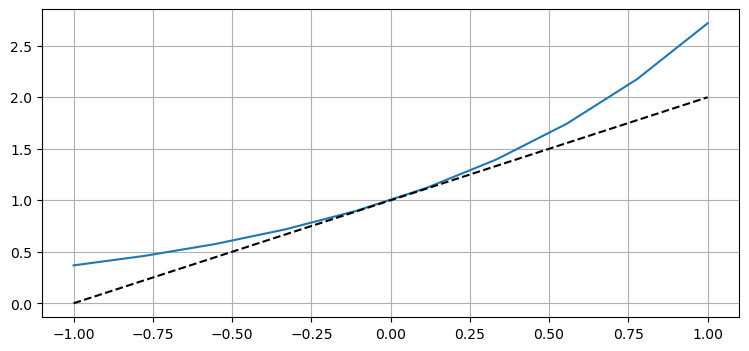

In [14]:
import matplotlib.pyplot as plt

t = np.linspace(-1, 1, 10)
plt.plot(t, np.exp(t))
t = np.linspace(-1, 1, 2)
plt.plot(t,t+1, ls='--', c='k');

你可以看到，在 $t=0.1$ 处斜率非常接近曲线，但在 $t=1$ 处离曲线很远。但让我们暂时继续用步长 1。我们可以看到，在 $t=1$ 处 $y$ 的估计值是 2。现在我们可以通过取曲线在 $t=1$ 处的斜率并把它加到我们的初始估计上，来计算 $t=2$ 处的值。斜率用 $y'=y$ 计算，所以斜率是 2。

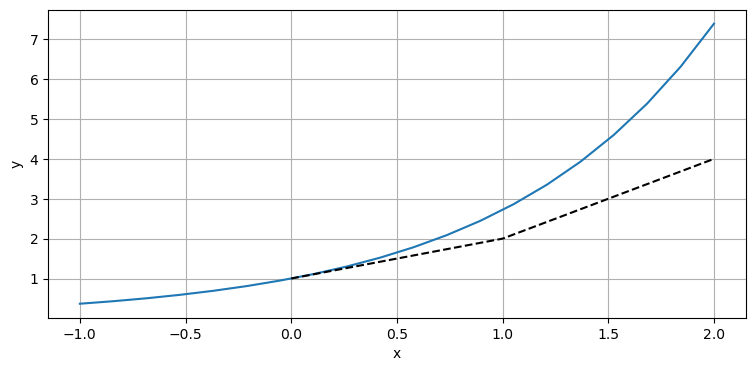

In [15]:
import kf_book.book_plots as book_plots

t = np.linspace(-1, 2, 20)
plt.plot(t, np.exp(t))
t = np.linspace(0, 1, 2)
plt.plot([1, 2, 4], ls='--', c='k')
book_plots.set_labels(x='x', y='y');

在这里我们看到 y 的下一个估计是 4。误差很快变大，你可能觉得没什么了不起。但 1 是一个非常大的步长。让我们把这个算法写成代码，并通过使用小步长来验证它有效。

In [16]:
def euler(t, tmax, y, dx, step=1.):
    ys = []
    while t < tmax:
        y = y + step*dx(t, y)
        ys.append(y)
        t +=step        
    return ys

In [17]:
def dx(t, y): return y

print(euler(0, 1, 1, dx, step=1.)[-1])
print(euler(0, 2, 1, dx, step=1.)[-1])

2.0
4.0


这看起来是正确的。所以现在让我们绘制步长小得多的结果。

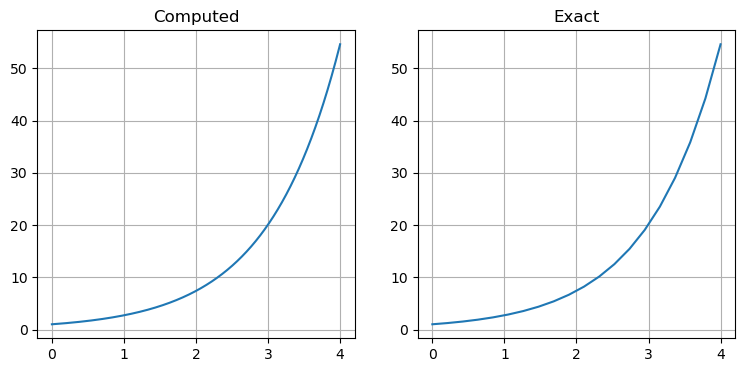

In [18]:
ys = euler(0, 4, 1, dx, step=0.00001)
plt.subplot(1,2,1)
plt.title('Computed')
plt.plot(np.linspace(0, 4, len(ys)),ys)
plt.subplot(1,2,2)
t = np.linspace(0, 4, 20)
plt.title('Exact')
plt.plot(t, np.exp(t));

In [19]:
print('exact answer=', np.exp(4))
print('euler answer=', ys[-1])
print('difference =', np.exp(4) - ys[-1])
print('iterations =', len(ys))

exact answer= 54.598150033144236
euler answer= 54.59705808834125
difference = 0.0010919448029866885
iterations = 400000


这里我们看到误差相当小，但要得到三位有效数字的精度，需要非常多的迭代次数。在实践中，欧拉方法对大多数问题来说太慢了，我们使用更复杂的方法。

在继续之前，让我们正式推导欧拉方法，因为它是下一节使用的更高级的 Runge Kutta 方法的基础。事实上，欧拉方法是 Runge Kutta 的最简单形式。


这里是 $y$ 的泰勒展开的前 3 项。无穷展开会给出精确答案，所以 $O(h^4)$ 表示有限展开造成的误差。

$$y(t_0 + h) = y(t_0) + h y'(t_0) + \frac{1}{2!}h^2 y''(t_0) + \frac{1}{3!}h^3 y'''(t_0) +  O(h^4)$$

这里我们可以看到，欧拉方法使用的是泰勒展开的前两项。每一后续项都比前面的项小，所以我们可以确信估计不会偏离正确值太远。

### 龙格-库塔方法


龙格-库塔 (Runge Kutta) 是数值积分的主力。文献中有大量的方法。在实践中，使用我在这里介绍的 Runge Kutta 算法可以解决你将面对的几乎所有问题。它在速度、精度和稳定性之间提供了非常好的平衡，除非你有非常好的理由选择别的方法，否则它就是“首选”的数值积分方法。

让我们深入研究。我们从某个微分方程开始

$$\ddot{y} = \frac{d}{dt}\dot{y}$$。

我们可以用函数 f 代替 y 的导数，像这样

$$\ddot{y} = \frac{d}{dt}f(y,t)$$。

推导这些方程超出了本书的范围，但 Runge Kutta RK4 方法由这些方程定义。

$$y(t+\Delta t) = y(t) + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4) + O(\Delta t^4)$$

$$\begin{aligned}
k_1 &= f(y,t)\Delta t \\
k_2 &= f(y+\frac{1}{2}k_1, t+\frac{1}{2}\Delta t)\Delta t \\
k_3 &= f(y+\frac{1}{2}k_2, t+\frac{1}{2}\Delta t)\Delta t \\
k_4 &= f(y+k_3, t+\Delta t)\Delta t
\end{aligned}
$$

这是相应的代码：

In [20]:
def runge_kutta4(y, x, dx, f):
    """computes 4th order Runge-Kutta for dy/dx.
    y is the initial value for y
    x is the initial value for x
    dx is the difference in x (e.g. the time step)
    f is a callable function (y, x) that you supply 
    to compute dy/dx for the specified values.
    """
    
    k1 = dx * f(y, x)
    k2 = dx * f(y + 0.5*k1, x + 0.5*dx)
    k3 = dx * f(y + 0.5*k2, x + 0.5*dx)
    k4 = dx * f(y + k3, x + dx)
    
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6.

让我们用它来做一个简单的例子。设

$$\dot{y} = t\sqrt{y(t)}$$

初始值为

$$\begin{aligned}t_0 &= 0\\y_0 &= y(t_0) = 1\end{aligned}$$

max error 0.00005


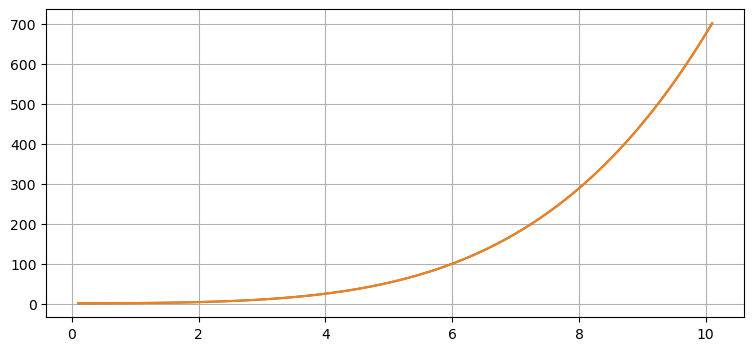

In [21]:
import math
import numpy as np
t = 0.
y = 1.
dt = .1

ys, ts = [], []

def func(y,t):
    return t*math.sqrt(y)

while t <= 10:
    y = runge_kutta4(y, t, dt, func)
    t += dt
    ys.append(y)
    ts.append(t)

exact = [(t**2 + 4)**2 / 16. for t in ts]
plt.plot(ts, ys)
plt.plot(ts, exact)

error = np.array(exact) - np.array(ys)
print(f"max error {max(error):.5f}")

## 贝叶斯滤波

从离散贝叶斯一章开始，我就使用贝叶斯的表述来做滤波。假设我们在跟踪一个物体。我们把它在特定时刻的*状态*定义为它的位置、速度等。例如，我们可以把时刻 $t$ 的状态写成 $\mathbf x_t = \begin{bmatrix}x_t &\dot x_t \end{bmatrix}^\mathsf T$。

当我们对物体进行测量时，我们测量的是状态或其一部分。传感器是有噪声的，所以测量值被噪声污染。不过显然，测量值是由状态决定的。也就是说，状态的改变可能改变测量值，但测量值的改变不会改变状态。

在滤波中，我们的目标是为从时刻 0 到时刻 $t$ 的一组状态 $\mathbf x_{0:t}$ 计算出最优估计。如果我们知道 $\mathbf x_{0:t}$，那么计算与这些状态对应的一组测量值 $\mathbf z_{0:t}$ 就很简单。然而，我们收到的是一组测量值 $\mathbf z_{0:t}$，想要计算对应的状态 $\mathbf x_{0:t}$。这称为*统计反演*，因为我们试图从输出计算输入。

反演是个困难的问题，因为通常没有唯一解。对于给定的一组状态 $\mathbf x_{0:t}$，只有一组可能的测量值（加噪声），但对于给定的一组测量值，有许多不同的状态组可能导致这些测量值。

回想贝叶斯定理：

$$P(x \mid z) = \frac{P(z \mid x)P(x)}{P(z)}$$

其中 $P(z \mid x)$ 是测量值 $z$ 的*似然*，$P(x)$ 是基于我们过程模型的*先验*，$P(z)$ 是归一化常数。$P(x \mid z)$ 是*后验*，即纳入测量值 $z$ 之后的分布，也称为*证据*。

这是一个*统计反演*，因为它从 $P(z \mid x)$ 变成 $P(x \mid z)$。我们滤波问题的解可以表示为：

$$P(\mathbf x_{0:t} \mid \mathbf z_{0:t}) = \frac{P(\mathbf z_{0:t} \mid \mathbf x_{0:t})P(\mathbf x_{0:t})}{P(\mathbf z_{0:t})}$$

在下一个测量值 $\mathbf z_{t+1}$ 到来之前，这一切都很好，到来之后我们需要对范围 $0:t+1$ 重新计算整个表达式。

在实践中这是不可行的，因为我们试图计算的是整个时间步范围内状态的后验分布 $P(\mathbf x_{0:t} \mid \mathbf z_{0:t})$。但是，当我们刚刚收到第十个测量值时，我们真的关心（比如）第三步的概率分布吗？通常不。所以我们放宽要求，只计算当前时间步的分布。

第一个简化是，我们把过程（例如运动物体的运动模型）描述为*马尔可夫链*。也就是说，我们说当前状态只取决于前一个状态和一个转移概率 $P(\mathbf x_k \mid \mathbf x_{k-1})$，这只是从上一个状态转到当前状态的概率。我们写成：

$$\mathbf x_k \sim P(\mathbf x_k \mid \mathbf x_{k-1})$$

在实践中这是极其合理的，因为许多事物都具有*马尔可夫性质*。如果你在停车场开车，你下一秒的位置取决于你一分钟前是刚下高速公路，还是正在土路上缓慢爬行吗？不取决于。你下一秒的位置完全取决于你当前的位置、速度和控制输入，而不取决于一分钟前发生了什么。因此，汽车具有马尔可夫性质，我们可以做这种简化，而不损失精度或一般性。

我们做的下一个简化是把*测量模型*定义为取决于当前状态 $\mathbf x_k$，用给定当前状态时测量值的条件概率表示：$P(\mathbf z_k \mid \mathbf x_k)$。我们写成：

$$\mathbf z_k \sim P(\mathbf z_k \mid \mathbf x_k)$$

现在我们有了一个递推，所以需要一个初始条件来终止它。因此我们说初始分布是状态 $\mathbf x_0$ 的概率：

$$\mathbf x_0 \sim P(\mathbf x_0)$$


这些项被代入贝叶斯方程。如果我们有状态 $\mathbf x_0$ 和第一个测量值，就可以估计 $P(\mathbf x_1 | \mathbf z_1)$。运动模型产生先验 $P(\mathbf x_2 \mid \mathbf x_1)$。我们把它反馈回贝叶斯定理，计算 $P(\mathbf x_2 | \mathbf z_2)$。我们继续这个预测-校正算法，仅基于时刻 $t-1$ 的状态和分布以及时刻 $t$ 的测量值，递归地计算时刻 $t$ 的状态和分布。

这一计算的数学细节因问题而异。**离散贝叶斯**和**一元卡尔曼滤波器**两章给出了两种不同的表述，你应该已经能够推理清楚。一元卡尔曼滤波器假设，对于标量状态，噪声和过程这两个线性模型都受到零均值、不相关的高斯噪声的影响。

多元卡尔曼滤波器做出相同的假设，但针对的是向量而不是标量的状态和测量值。Kalman 博士能够证明，如果这些假设成立，那么卡尔曼滤波器在最小二乘意义上是*最优*的。通俗地说，这意味着没有办法从有噪声的测量值中获取更多信息。在本书的其余部分，我将介绍放宽线性和高斯噪声约束的滤波器。

在继续之前，再多说几句关于统计反演的话。正如 Calvetti 和 Somersalo 在《贝叶斯科学计算导论》(*Introduction to Bayesian Scientific Computing*) 中所写：“我们采用贝叶斯的观点：*随机性仅仅意味着缺乏信息*”[3]。我们的状态参数化了我们原则上可以测量或计算的物理现象：速度、空气阻力，等等。我们缺乏足够的信息来计算或测量它们的值，所以选择把它们视为随机变量。严格地说，它们并不是随机的，因此这是一种主观的立场。

他们用整整一章来讨论这个主题。我只能匀出一段。贝叶斯滤波器之所以可能，是因为我们把统计性质赋予了未知参数。在卡尔曼滤波器的情形中，我们有封闭形式的解来求最优估计。其他滤波器，例如离散贝叶斯滤波器或我们将在后面章节讲的粒子滤波器，则以更临时的、非最优的方式对概率建模。我们这种技术的威力来自于把信息的缺乏视为随机变量，把该随机变量描述为概率分布，然后用贝叶斯定理来解决统计推断问题。

## 把卡尔曼滤波器转换为 g-h 滤波器

我曾说过卡尔曼滤波器是 g-h 滤波器的一种形式。只需要一些代数就可以证明这一点。用一维情形来做更直截了当，所以我就这样做。回想

$$
\mu_{x}=\frac{\sigma_1^2 \mu_2 + \sigma_2^2 \mu_1} {\sigma_1^2 + \sigma_2^2}
$$

我把它改写成对我们的眼睛更友好的形式：

$$
\mu_{x}=\frac{ya + xb} {a+b}
$$

我们可以用下面的代数轻松地把它化成 g-h 形式

$$
\begin{aligned}
\mu_{x}&=(x-x) + \frac{ya + xb} {a+b} \\
\mu_{x}&=x-\frac{a+b}{a+b}x  + \frac{ya + xb} {a+b} \\
\mu_{x}&=x +\frac{-x(a+b) + xb+ya}{a+b} \\
\mu_{x}&=x+ \frac{-xa+ya}{a+b}  \\
\mu_{x}&=x+ \frac{a}{a+b}(y-x)\\
\end{aligned}
$$

我们快完成了，但回想一下，估计的方差由下式给出

$$\begin{aligned}
\sigma_{x}^2 &= \frac{1}{\frac{1}{\sigma_1^2} +  \frac{1}{\sigma_2^2}} \\
&= \frac{1}{\frac{1}{a} +  \frac{1}{b}}
\end{aligned}$$

我们可以通过观察下式，把这一项纳入上面的方程

$$
\begin{aligned}
\frac{a}{a+b} &= \frac{a/a}{(a+b)/a} = \frac{1}{(a+b)/a}  \\
 &= \frac{1}{1 + \frac{b}{a}} = \frac{1}{\frac{b}{b} + \frac{b}{a}}  \\
 &= \frac{1}{b}\frac{1}{\frac{1}{b} + \frac{1}{a}} \\
 &= \frac{\sigma^2_{x}}{b}
 \end{aligned}
$$

我们可以把这一切联系起来

$$
\begin{aligned}
\mu_{x}&=x+ \frac{a}{a+b}(y-x) \\
&= x + \frac{\sigma^2_{x}}{b}(y-x) \\
&= x + g_n(y-x)
\end{aligned}
$$

其中

$$g_n = \frac{\sigma^2_{x}}{\sigma^2_{y}}$$

最终结果是把两个测量值的残差乘以一个常数，再加到我们之前的值上，这就是 g-h 滤波器的 $g$ 方程。$g$ 是新估计的方差除以测量的方差。当然，在这种情况下 $g$ 不是常数，因为它随每个时间步的方差变化而变化。我们也可以用同样的方式推导 $h$ 的公式。这个推导并不特别有启发性，我将跳过。最终结果是

$$h_n = \frac{COV (x,\dot x)}{\sigma^2_{y}}$$

要点是，$g$ 和 $h$ 完全由时刻 $n$ 的测量值和预测的方差与协方差所确定。换句话说，我们是按由这两个输入各自的质量决定的缩放因子，在测量值与预测之间选取一个点。

## 参考文献

 * [1] C.B. Molwer and C.F. Van Loan "Nineteen Dubious Ways to Compute the Exponential of a Matrix, Twenty-Five Years Later,", *SIAM Review 45, 3-49*. 2003.


 * [2] C.F. van Loan, "Computing Integrals Involving the Matrix Exponential," IEEE *Transactions Automatic Control*, June 1978.


 * [3] Calvetti, D and Somersalo E, "Introduction to Bayesian Scientific Computing: Ten Lectures on Subjective Computing,", *Springer*, 2007.

 * [4] Brown, R. G. and Hwang, P. Y.C., "Introduction to Random Signals and Applied Kalman Filtering", *Wiley and Sons*, Fourth Edition, p.143-147, 2012.